In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')


from spikeparam.patch.fit import Spike
from spikeparam.patch.fit import SpikeGroup



from neurodsp import spectral

from scipy import signal
import scipy

import h5py
from tqdm.notebook import tqdm

import numpy as np
import pandas as pd

from neurodsp import filt
from neurodsp.timefrequency import amp_by_time, phase_by_time
from neurodsp.plts import plot_time_series, plot_instantaneous_measure
from neurodsp.plts.time_series import plot_bursts
from neurodsp.burst import detect_bursts_dual_threshold, compute_burst_stats

from scipy.signal import sosfiltfilt, butter

from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sns

import os

from fooof import FOOOF

sns.set(rc={'figure.figsize':(12,9)})
sns.set_style('whitegrid')
sns.set_style("whitegrid", {'axes.grid' : False})


In [3]:
def butter_bandpass(data, fs, filt_freq, order):
    # make sure that the user provides two frequencies for bandpass filter
    try:
        # renormalize frequencies in Hz to fractional scale required by butter
        nyq = 0.5 * fs # nyquist frequency
        f0 = (filt_freq[0]/nyq)
        f1 = (filt_freq[1]/nyq)

        # highpass first
        sos = butter(order, f0, btype = 'high', analog=False, output='sos')
        y = sosfiltfilt(sos, data)

        # then lowpass
        sos = butter(order, f1, btype = 'low', analog=False, output='sos')
        y = sosfiltfilt(sos, y)
        
        return y
    
    except:
        print("filt_freq must have two frequencies for a bandpass filter")

In [4]:
# open and load the neuropixel spiking data
"""
filedir = 'datasets/spe-1/EAP-Yes/c14/'

# load npx data
npx_path = filedir + 'c14_npx_raw.bin'
npx_fs = 30000 # sampling rate
npx_one_ms = int(npx_fs / 1000)
npx_channels = 384
npx_patch_channel = 161
npx_recording = np.memmap(npx_path, mode = 'r', dtype=np.int16, order = 'C')
npx_samples = int(len(npx_recording)/npx_channels)
npx_recording = npx_recording.reshape((npx_channels, npx_samples), order = 'F')
npx_recording = npx_recording[npx_patch_channel, :]
npx_recording = np.asarray(npx_recording)

npx_times = np.arange(0, np.shape(npx_recording)[0]) / npx_one_ms # in ms instead of sec


# filter the neuropixels data
npx_filt = butter_bandpass(npx_recording, fs=npx_fs, filt_freq=[300, 14000], order=4)


np.save(filedir + 'npx_filt.npy', npx_filt)
"""


"\nfiledir = 'datasets/spe-1/EAP-Yes/c14/'\n\n# load npx data\nnpx_path = filedir + 'c14_npx_raw.bin'\nnpx_fs = 30000 # sampling rate\nnpx_one_ms = int(npx_fs / 1000)\nnpx_channels = 384\nnpx_patch_channel = 161\nnpx_recording = np.memmap(npx_path, mode = 'r', dtype=np.int16, order = 'C')\nnpx_samples = int(len(npx_recording)/npx_channels)\nnpx_recording = npx_recording.reshape((npx_channels, npx_samples), order = 'F')\nnpx_recording = npx_recording[npx_patch_channel, :]\nnpx_recording = np.asarray(npx_recording)\n\nnpx_times = np.arange(0, np.shape(npx_recording)[0]) / npx_one_ms # in ms instead of sec\n\n\n# filter the neuropixels data\nnpx_filt = butter_bandpass(npx_recording, fs=npx_fs, filt_freq=[300, 14000], order=4)\n\n\nnp.save(filedir + 'npx_filt.npy', npx_filt)\n"

In [5]:
"""

# # open and load the data
data_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/lfp_recordings/lfp_recordingsD/'
lfp_fs = 2500 # sampling rate
lfp_one_ms = int(lfp_fs / 1000)
npx_channels = 384
#loop through lfp recording folder
for filename in tqdm(os.listdir(data_path)):

    recfile = os.path.join(data_path, filename)

    if recfile.endswith('.bin'):


        #get cell number 
        cell_num = recfile.split('_')[4].split('/')[1]
      
        #Load LFP data
        lfp_recording = np.memmap(recfile, mode = 'r', dtype=np.int16, order = 'C')
        lfp_samples = int(len(lfp_recording)/npx_channels)
        lfp_recording = lfp_recording.reshape((lfp_samples, npx_channels), order = 'F')
        lfp_recording = lfp_recording[:, npx_patch_channel]
        lfp_recording = np.asarray(lfp_recording)
        lfp_recording = lfp_recording - np.mean(lfp_recording) # de-mean

        lfp_times = np.arange(0, np.shape(lfp_recording)[0]) / lfp_one_ms # in ms instead of sec

        # # filter the patch data
        # patch_filt = butter_bandpass(patch_recording, fs=patch_fs, filt_freq=[10, 25000], order=4)
        # # filter the neuropixels data
        # npx_filt = butter_bandpass(npx_recording, fs=npx_fs, filt_freq=[300, 14000], order=4)
        # # filter the LFP data
        lfp_filt = butter_bandpass(lfp_recording, fs=lfp_fs, filt_freq=[0.1, 250], order=4)

        # np.save(filedir + 'patch_filt.npy', patch_filt)
        # np.save(filedir + 'npx_filt.npy', npx_filt)
        np.save(data_path + cell_num + '_lfp_filt.npy', lfp_filt)


"""


"\n\n# # open and load the data\ndata_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/lfp_recordings/lfp_recordingsD/'\nlfp_fs = 2500 # sampling rate\nlfp_one_ms = int(lfp_fs / 1000)\nnpx_channels = 384\n#loop through lfp recording folder\nfor filename in tqdm(os.listdir(data_path)):\n\n    recfile = os.path.join(data_path, filename)\n\n    if recfile.endswith('.bin'):\n\n\n        #get cell number \n        cell_num = recfile.split('_')[4].split('/')[1]\n      \n        #Load LFP data\n        lfp_recording = np.memmap(recfile, mode = 'r', dtype=np.int16, order = 'C')\n        lfp_samples = int(len(lfp_recording)/npx_channels)\n        lfp_recording = lfp_recording.reshape((lfp_samples, npx_channels), order = 'F')\n        lfp_recording = lfp_recording[:, npx_patch_channel]\n        lfp_recording = np.asarray(lfp_recording)\n        lfp_recording = lfp_recording - np.mean(lfp_recording) # de-mean\n\n        lfp_times = np.arange(0,

### Look at neuropixel LFP PSDs for all "good" cells

  0%|          | 0/14 [00:00<?, ?it/s]

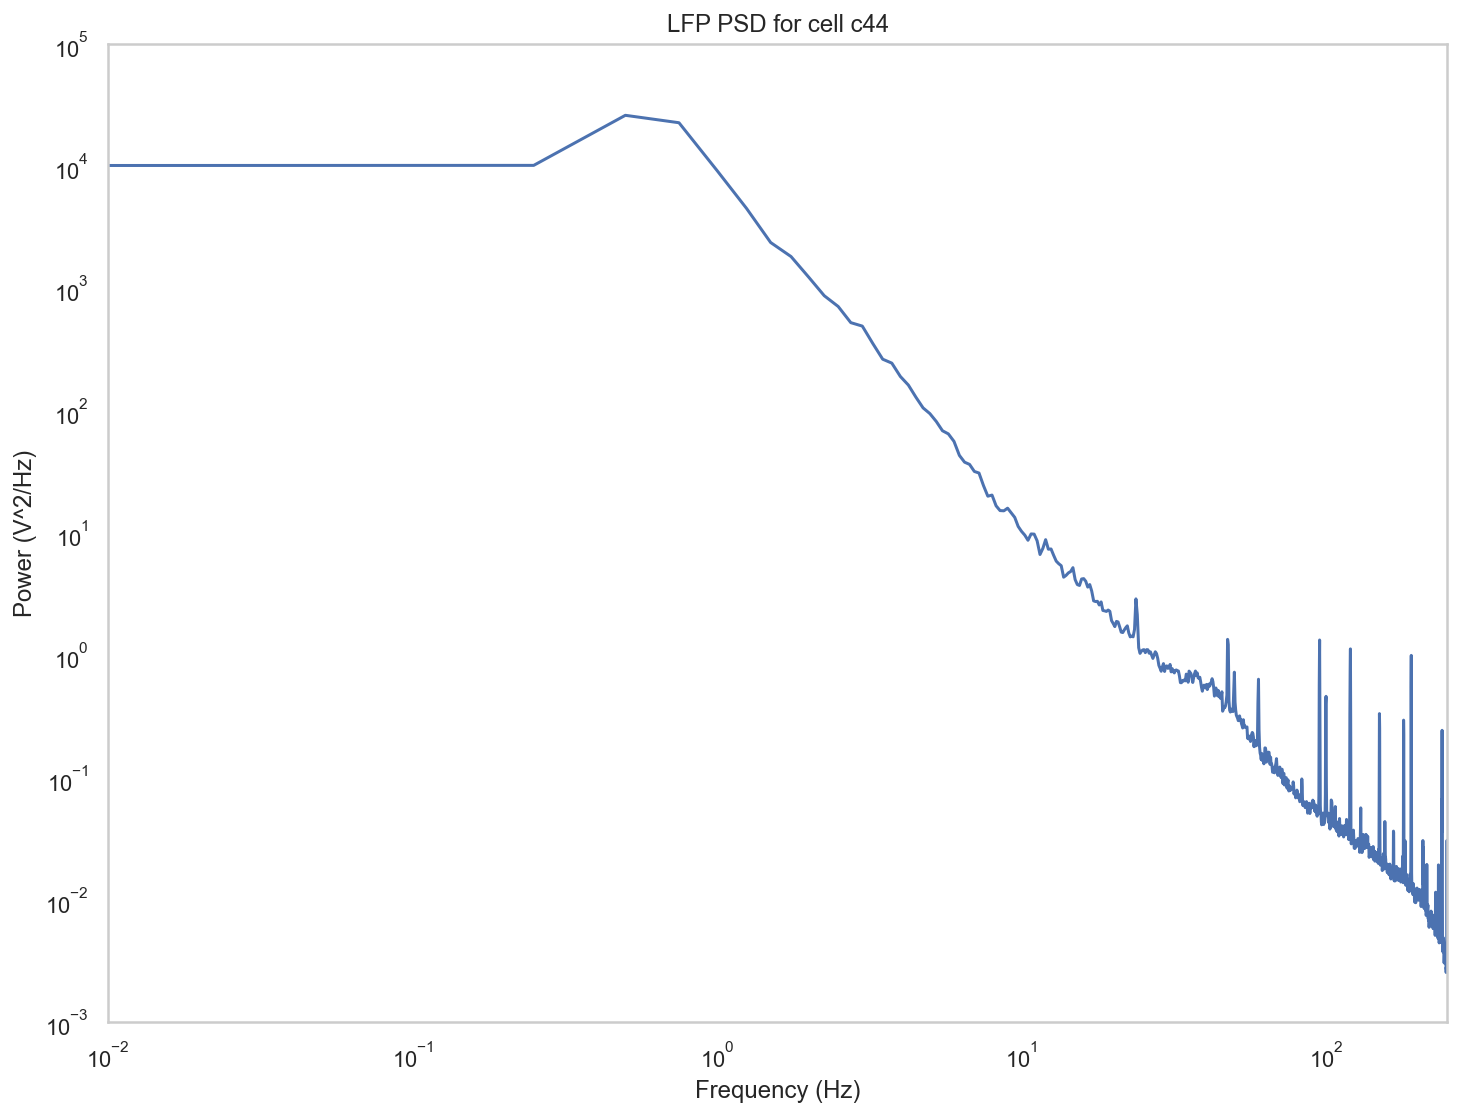

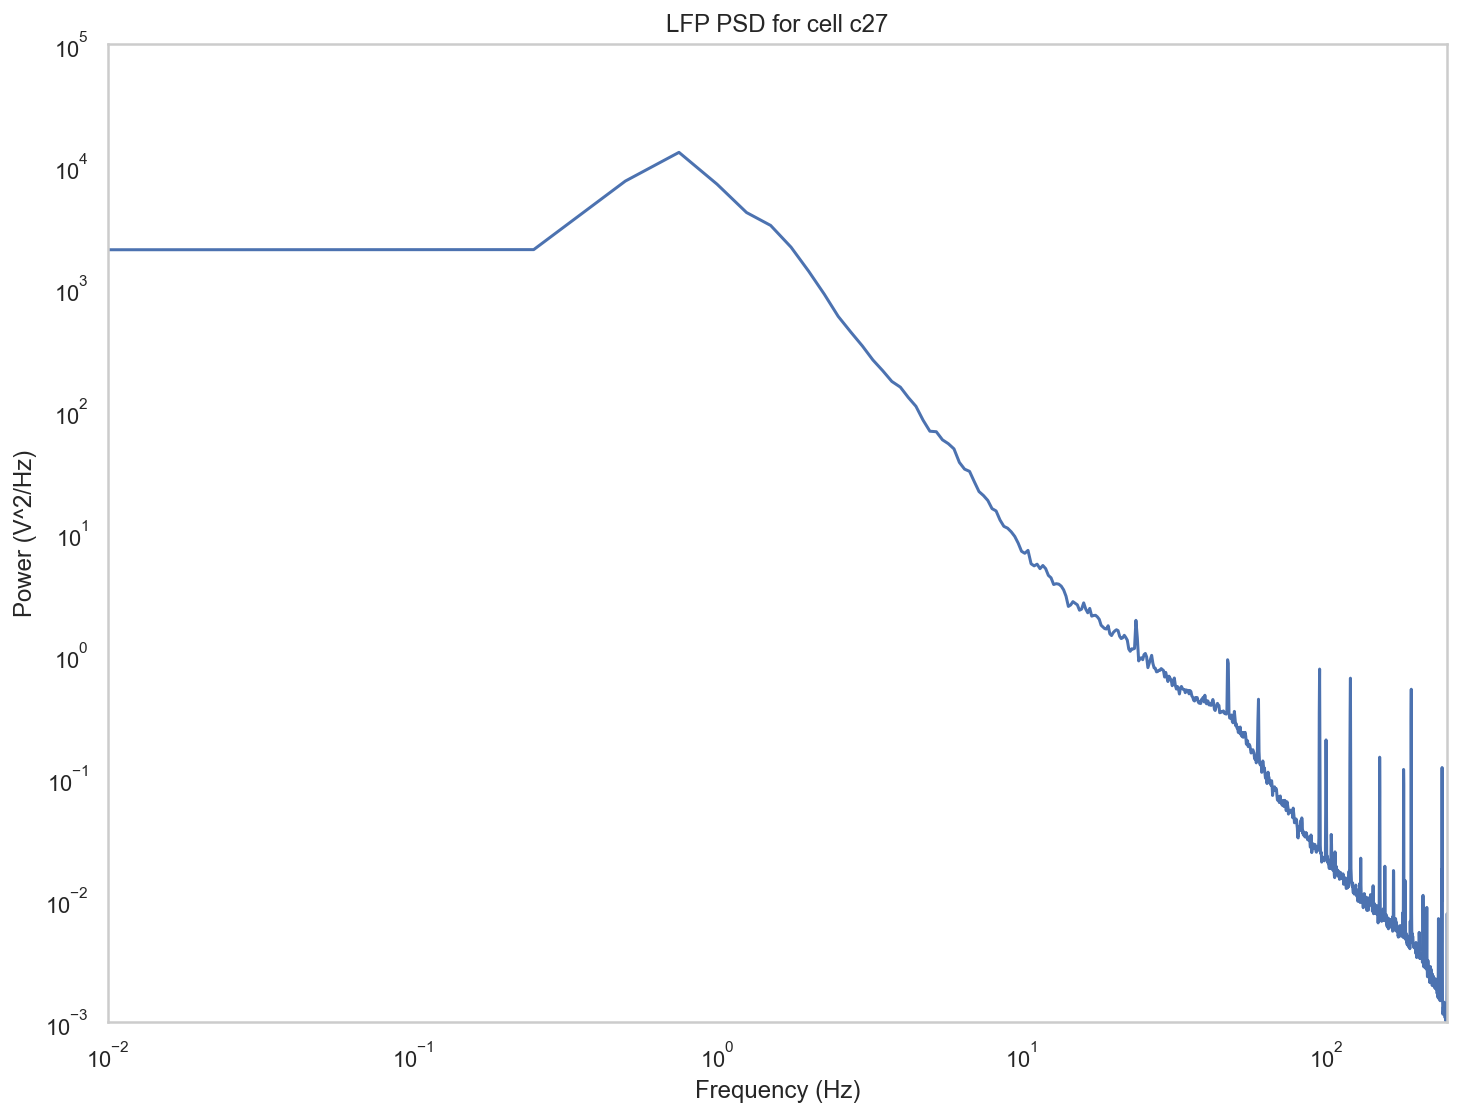

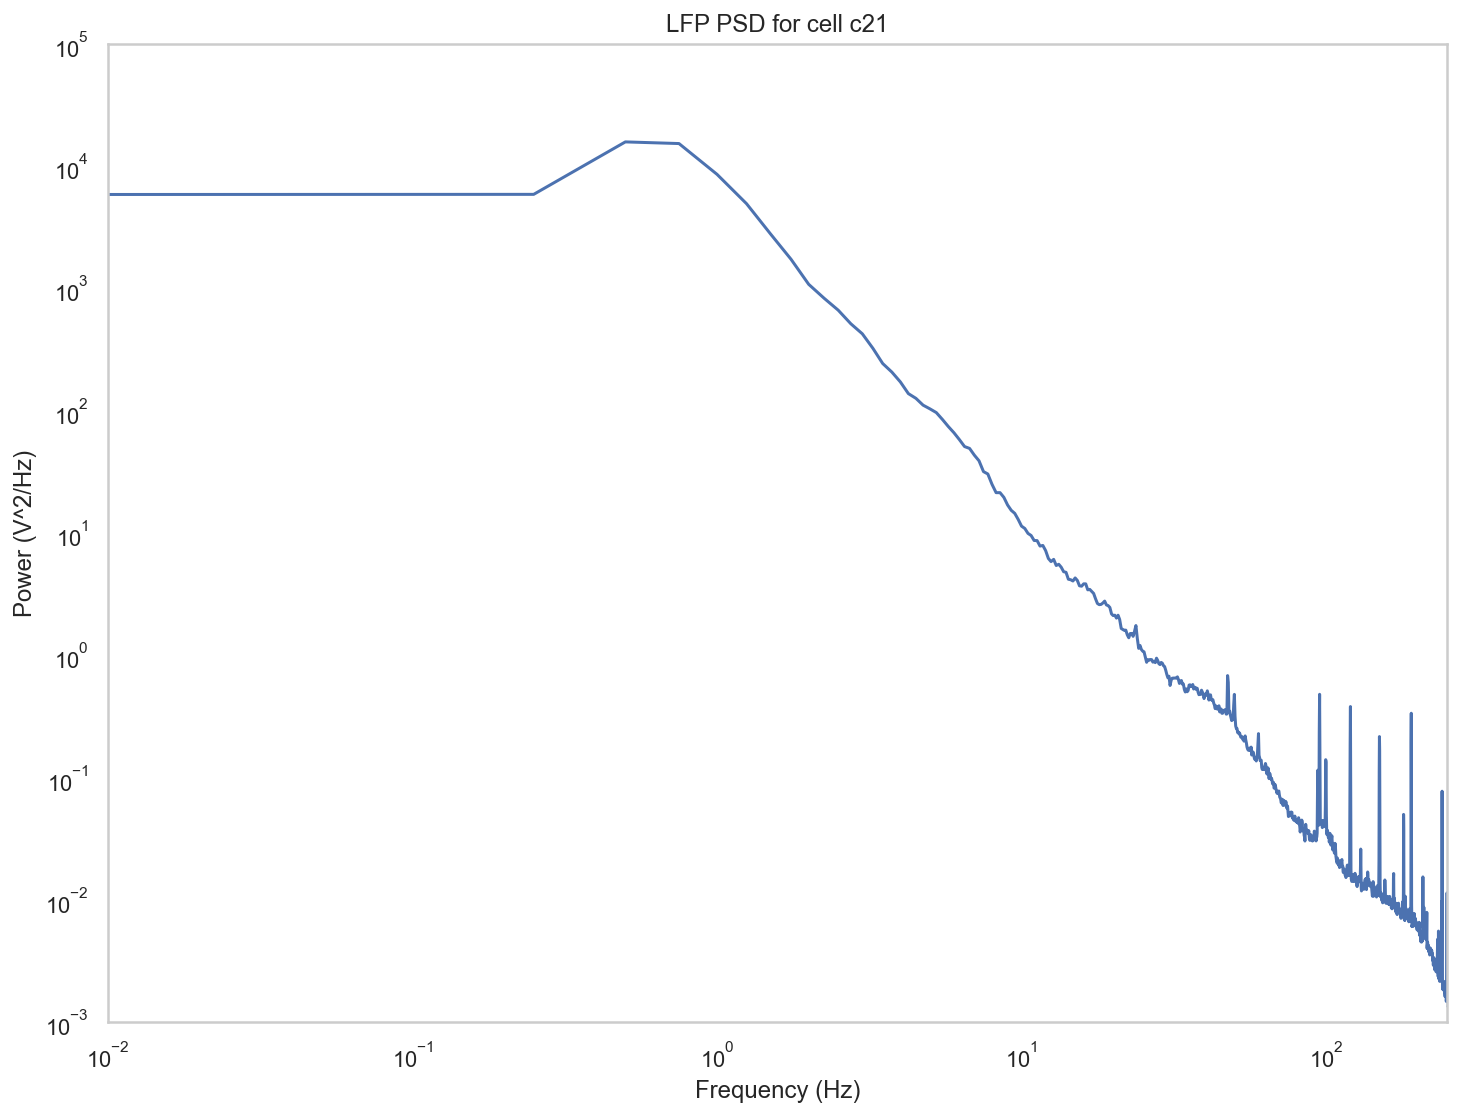

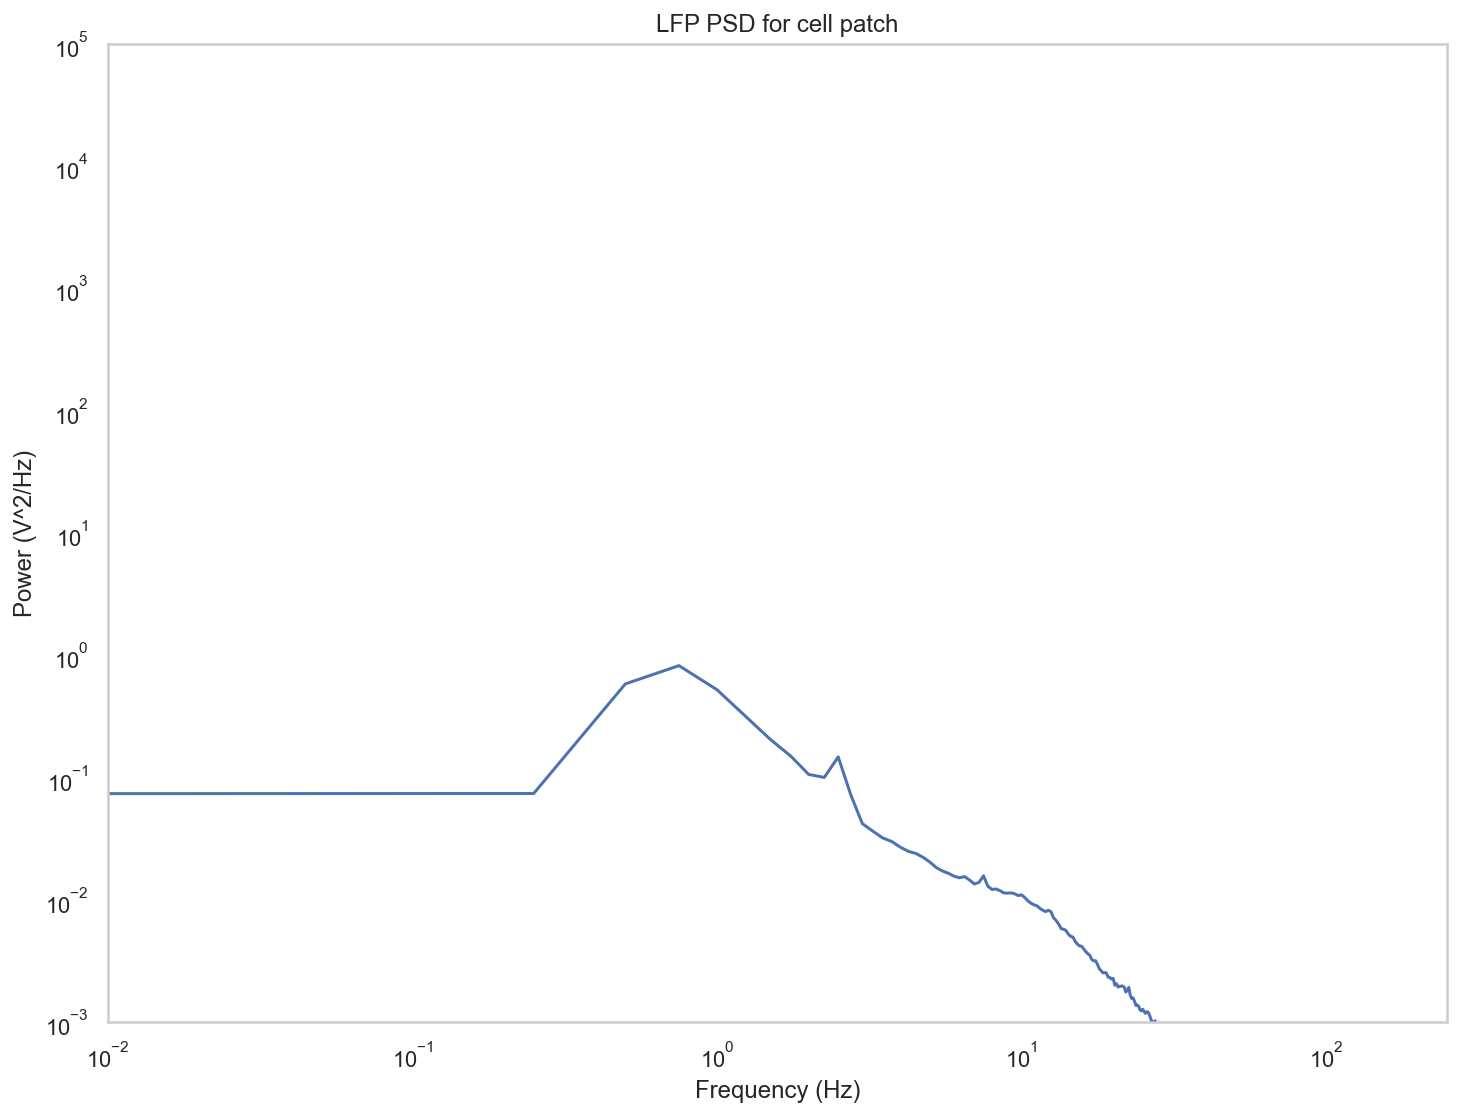

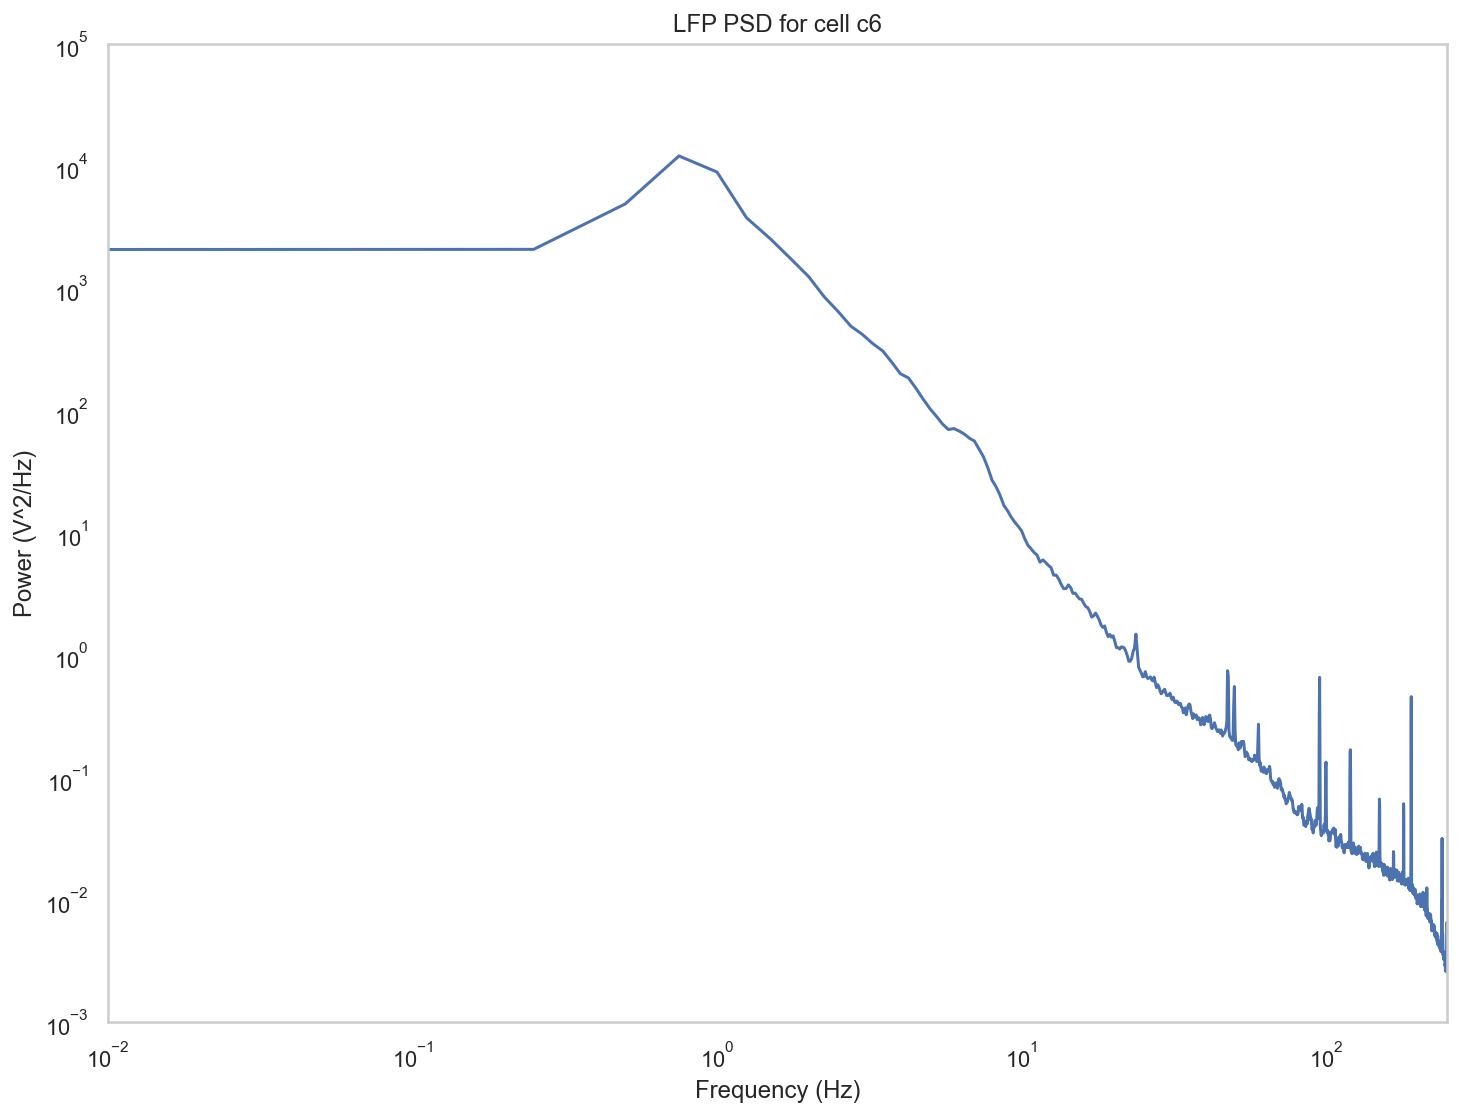

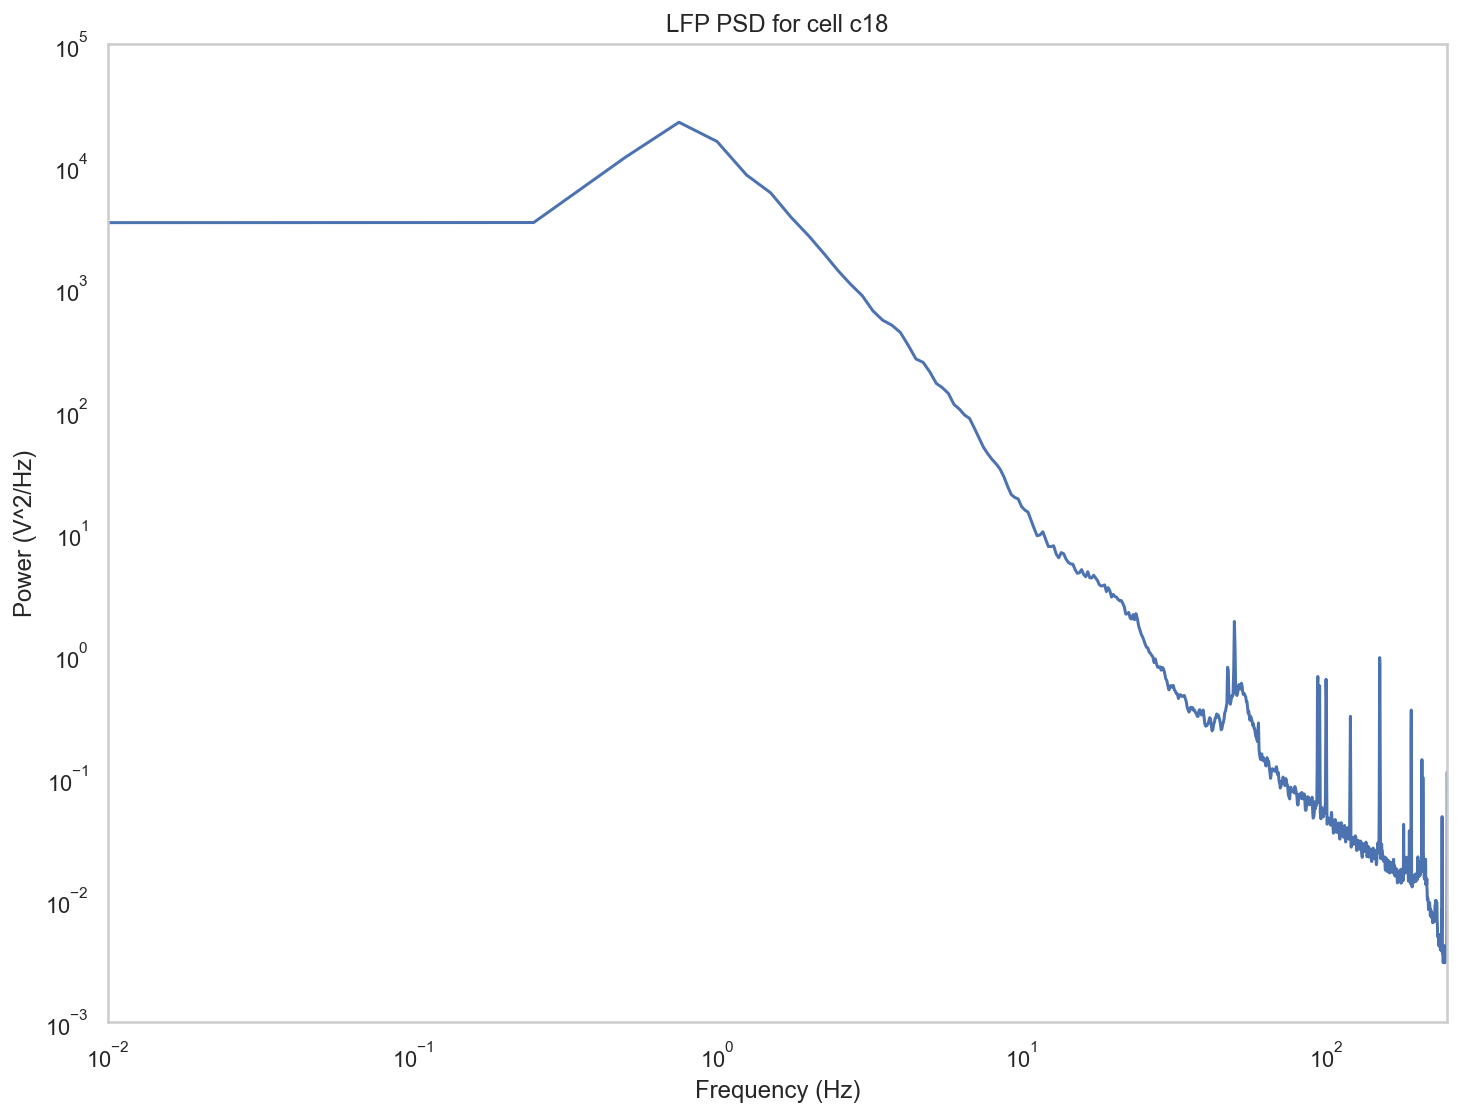

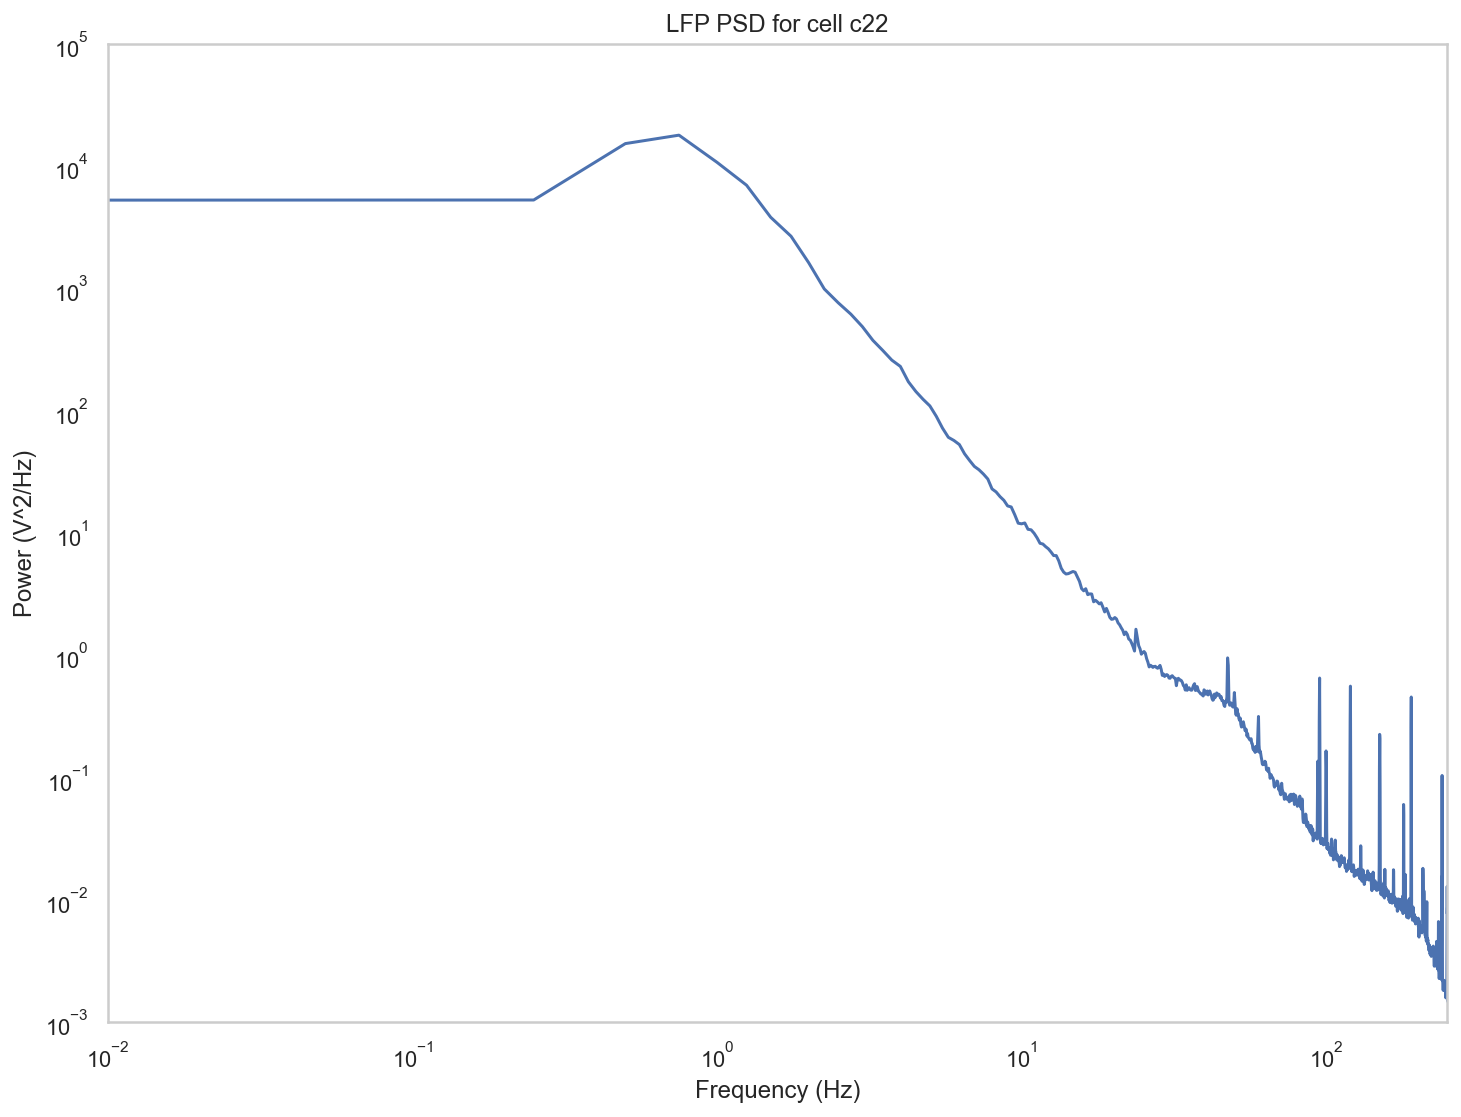

In [6]:
# open and load the data
filedir = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/lfp_recordings/lfp_recordingsD/'


for filename in tqdm(os.listdir(filedir)):

    lfpfile = os.path.join(filedir, filename)

    if lfpfile.endswith('.npy'):
        #get cell number 
        cell_num = lfpfile.split('/')[len(lfpfile.split('/'))-1].split('_')[0]
        #patch_filt = np.load(filedir + 'patch_filt.npy')
        #npx_filt = np.load(filedir + 'npx_filt.npy')
        lfp_filt = np.load(lfpfile)

        #patch_fs = 50023.88925263
        #patch_one_ms = int(patch_fs / 1000)

        #npx_fs = 30000 # sampling rate
        #npx_one_ms = int(npx_fs / 1000)

        lfp_fs = 2500 # sampling rate
        lfp_one_ms = int(lfp_fs / 1000)

        #patch_times = np.arange(0, np.shape(patch_filt)[0]) / patch_one_ms # in ms instead of sec
        #npx_times = np.arange(0, np.shape(npx_filt)[0]) / npx_one_ms # in ms instead of sec
        lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec
        
     
        # plot power spectrum
        fxx, pxx = spectral.compute_spectrum(lfp_filt, lfp_fs, method='welch', window='hann', nperseg=lfp_fs*4)

        xlim = (10e-3, 250)
        ylim = (10e-4, 10e4)
        plt.loglog(fxx, pxx)
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Power (V^2/Hz)')
        plt.xlim(xlim)
        plt.ylim(ylim)
        plt.title("LFP PSD for cell "+ cell_num)
        plt.show()


## Cell 42  (Whole patch, IC)
### Analze Gamma LFP and whole patch clamp AP relationship for cell 42

### LFP Gamma "burst detection" method

In [7]:
lfp_c42= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/lfp_recordings/lfp_recordingsC/c42_lfp_filt.npy'


In [8]:
#get cell number 
cell_num = lfp_c42.split('/')[len(lfp_c42.split('/'))-1].split('_')[0]

lfp_filt_c42 = np.load(lfp_c42)
lfp_fs = 2500 # sampling rate
lfp_one_ms = int(lfp_fs / 1000)
lfp_times_c42 = np.arange(0, np.shape(lfp_filt_c42)[0]) / lfp_one_ms # in ms instead of sec

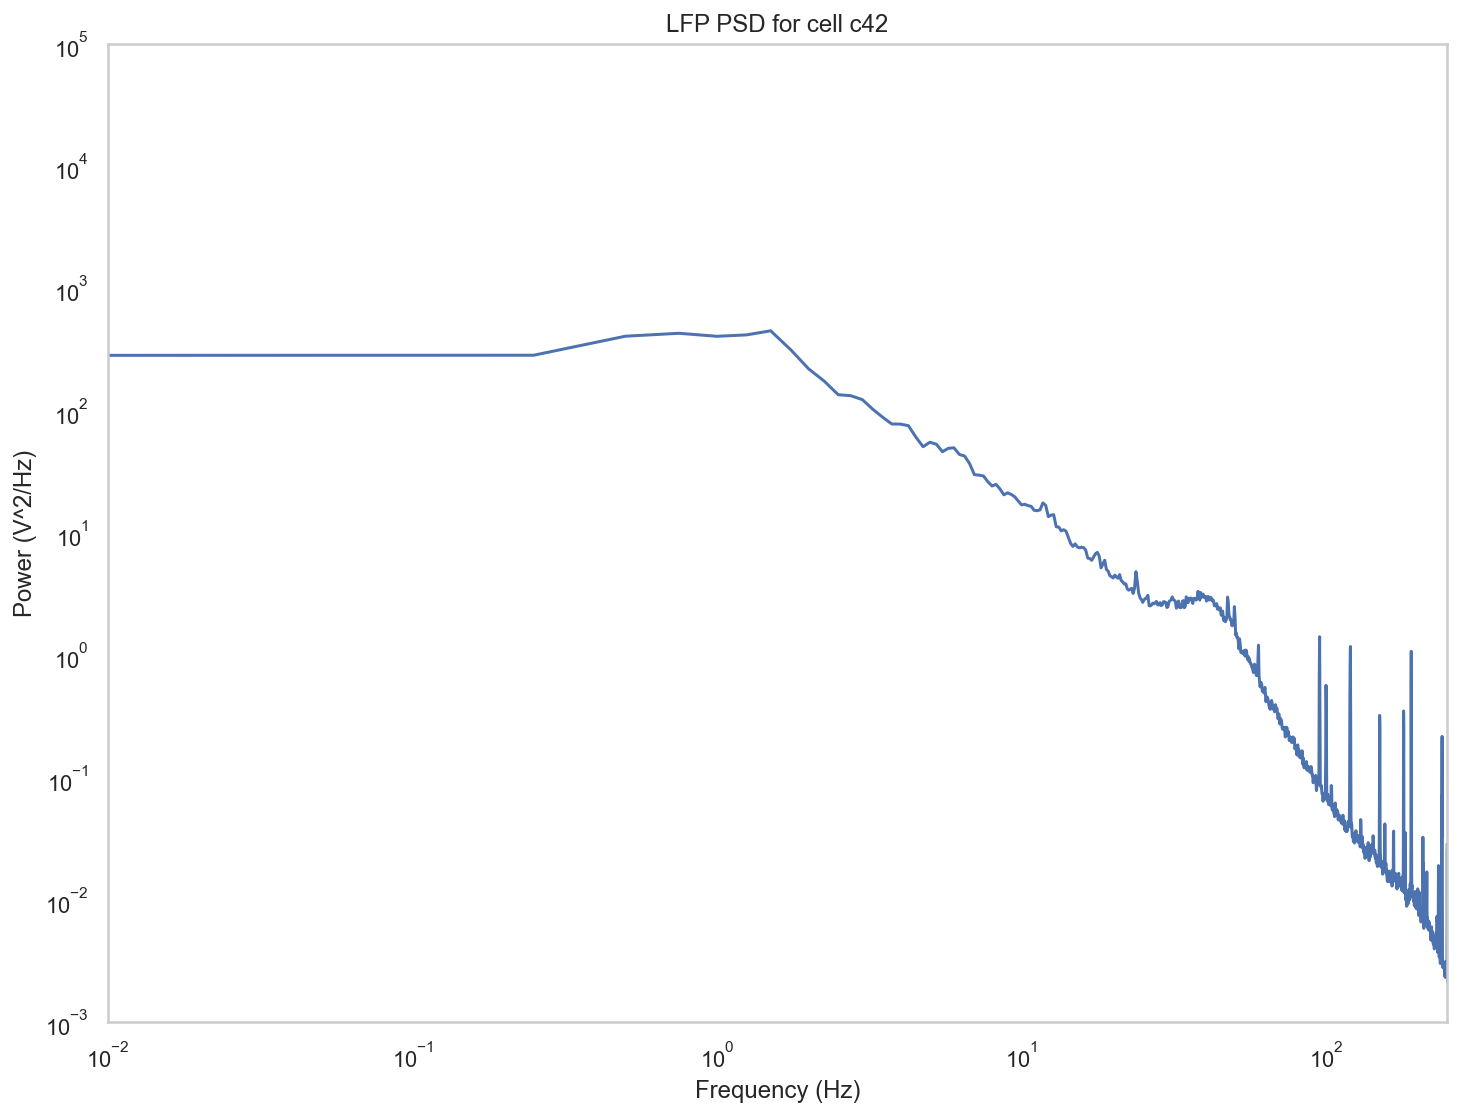

In [9]:
#plot PSD for cell 42
# plot power spectrum
fxx_c42, pxx_c42 = spectral.compute_spectrum(lfp_filt_c42, lfp_fs, method='welch', window='hann', nperseg=lfp_fs*4)

xlim = (10e-3, 250)
ylim = (10e-4, 10e4)
plt.loglog(fxx_c42, pxx_c42)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (V^2/Hz)')
plt.xlim(xlim)
plt.ylim(ylim)
plt.title("LFP PSD for cell "+ cell_num)
plt.show()


#### 0. Use specpram to find gamma peaks

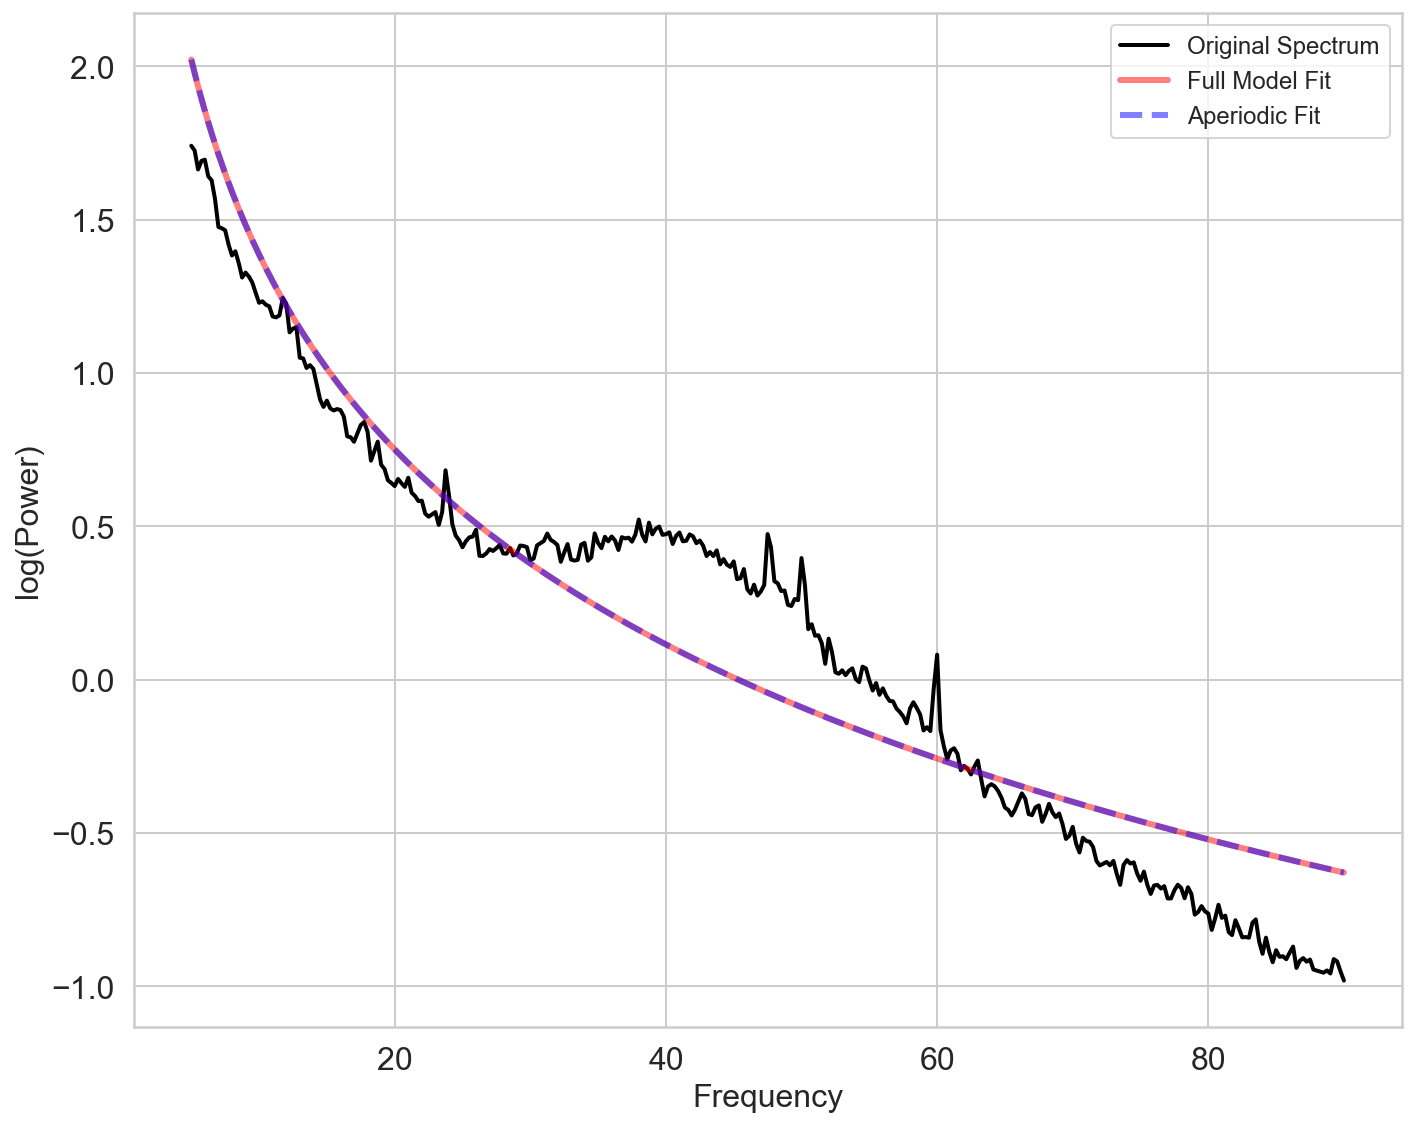

In [10]:
fm_c42 = FOOOF(max_n_peaks=0, verbose=False)
fm_c42.fit(fxx_c42, pxx_c42, freq_range=(5,90))
fm_c42.plot()

#### 1. Filter the signal in +/- 15 Hz around that gamma peak

In [11]:
gamma_peak = 40 #Hz 
gamma_range = [gamma_peak - 15, gamma_peak+15]
#filter LFP data around that range
lfp_filt_gamma_c42 = butter_bandpass(lfp_filt_c42, fs=lfp_fs, filt_freq=gamma_range, order=4)

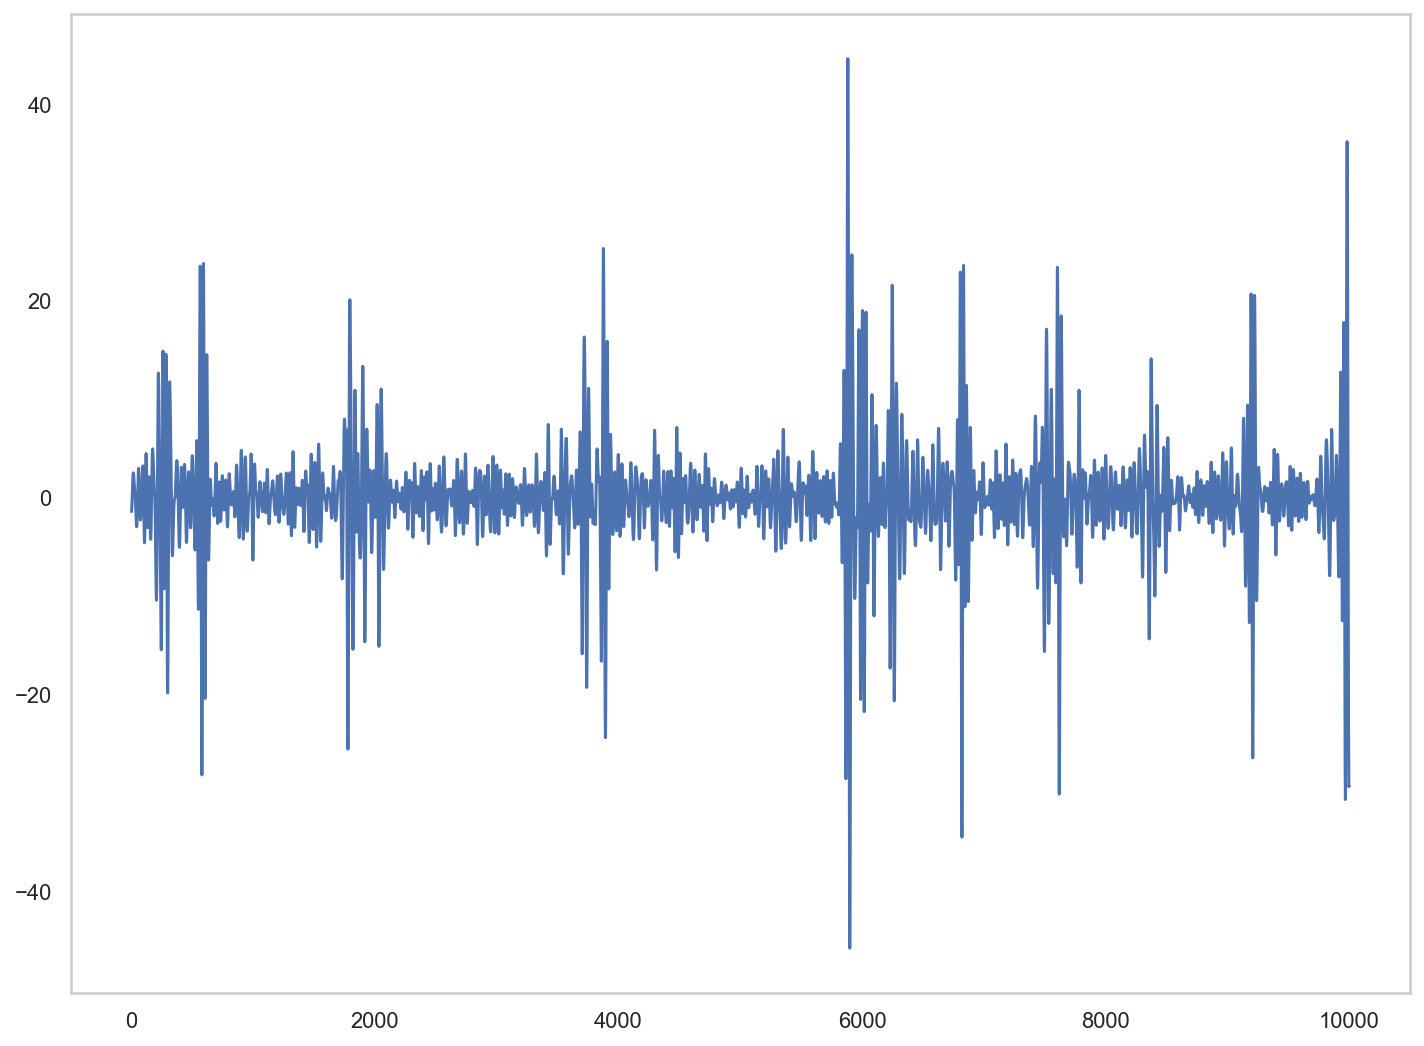

In [12]:
plt.plot(lfp_times_c42[:20000], lfp_filt_gamma_c42[:20000])

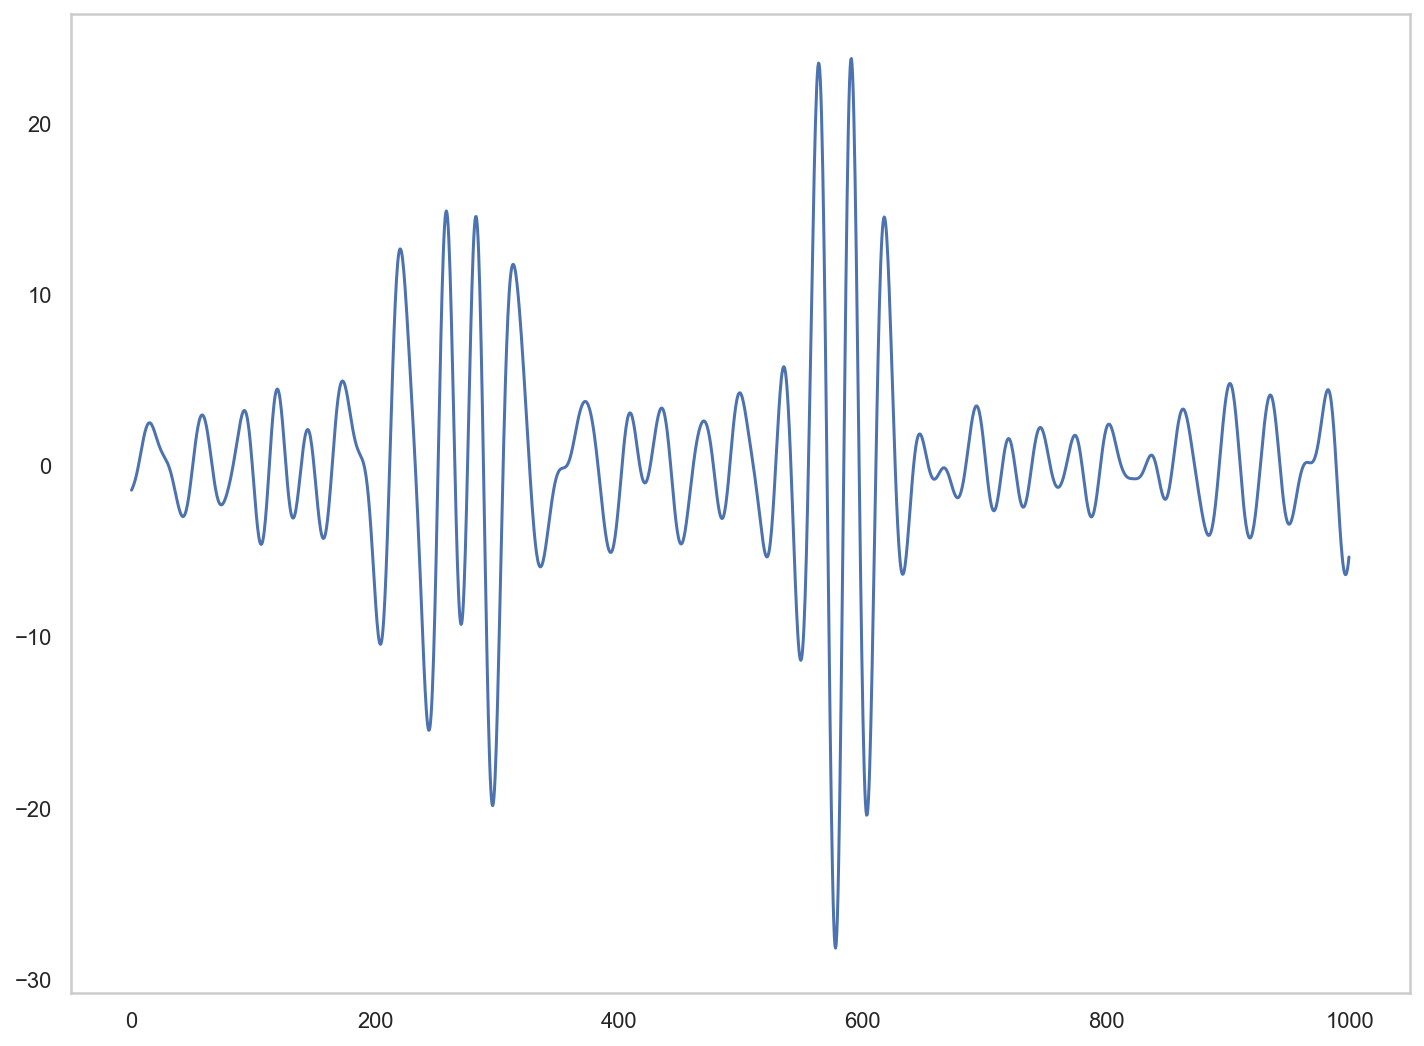

In [13]:
plt.plot(lfp_times_c42[:2000], lfp_filt_gamma_c42[:2000])

#### 2. Get the analytic amplitude of the time series 

In [14]:
gamma_amp = amp_by_time(lfp_filt_gamma_c42, lfp_fs, gamma_range)

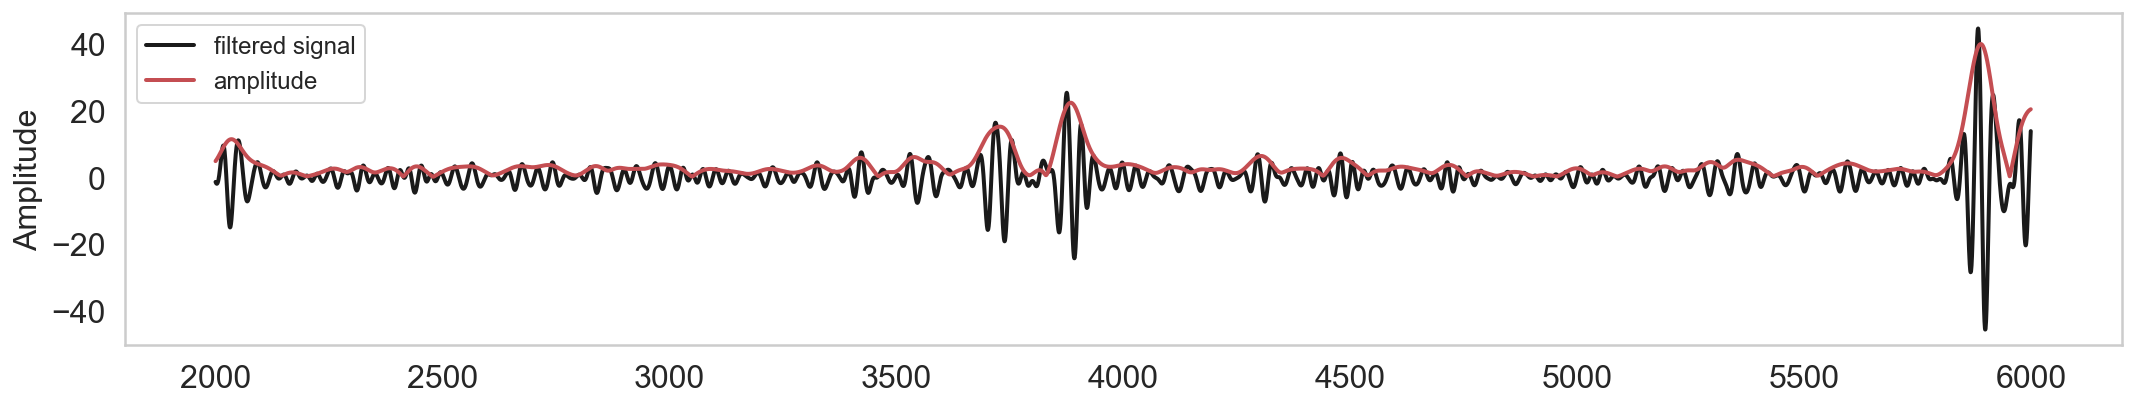

In [15]:
xlim = (2000, 6000)
tidx = np.logical_and(lfp_times_c42 >= xlim[0],lfp_times_c42 < xlim[1])

# Plot the filtered signal and oscillation amplitude
plot_instantaneous_measure(lfp_times_c42[tidx], [lfp_filt_gamma_c42[tidx], gamma_amp[tidx]],
                           measure='amplitude', lw=2, xlabel='',
                           labels=['filtered signal', 'amplitude'])

#### 3. Classify a burst as whenever the gamma analytic amplitude goes above some criterion (3x median, 2std of the mean, whatever), and ends when it drops below another criterion (1.5x mean, 1std of mean)


In [16]:
bthresh_start  = 3*np.nanmean(gamma_amp)
bthresh_end  = 1.5*np.nanmean(gamma_amp)

In [17]:
gamma_bursts = []
inburst_list = []


start_burst=False

#classify bursts following thresholds 
for i in range(len(lfp_times_c42)):
    
    if start_burst:
        inburst_list.append(True)

    else:
        inburst_list.append(False)

    if np.abs(lfp_filt_gamma_c42[i])>bthresh_start:
        start_burst = True
        start_idx = i
        
        
        
    elif np.abs(lfp_filt_gamma_c42[i])<bthresh_end and start_burst:
        end_idx = i
        
        gamma_bursts.append([start_idx, end_idx])
        start_burst = False
       
        
        
    
        
        
        
        


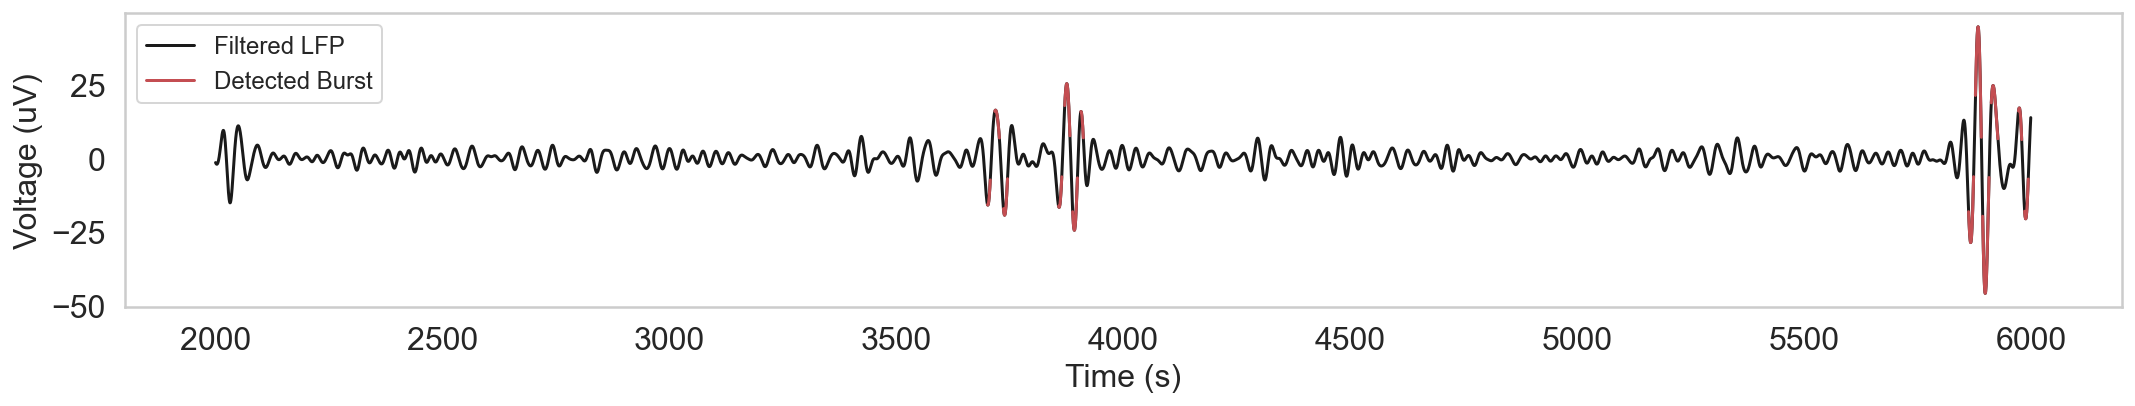

In [18]:
# Plot signal and burst activity
plot_bursts(lfp_times_c42[tidx], lfp_filt_gamma_c42[tidx], np.asarray(inburst_list)[tidx], labels=['Filtered LFP', 'Detected Burst'])


In [19]:
xlim = (1000,20000)
tidx = np.logical_and(lfp_times_c42 >= xlim[0],lfp_times_c42 < xlim[1])

In [20]:
###Try neurodsp burst detection method 
is_burst_gamma = detect_bursts_dual_threshold(lfp_filt_c42, lfp_fs, dual_thresh=(3, 1), f_range=(gamma_peak - 15, gamma_peak+15))


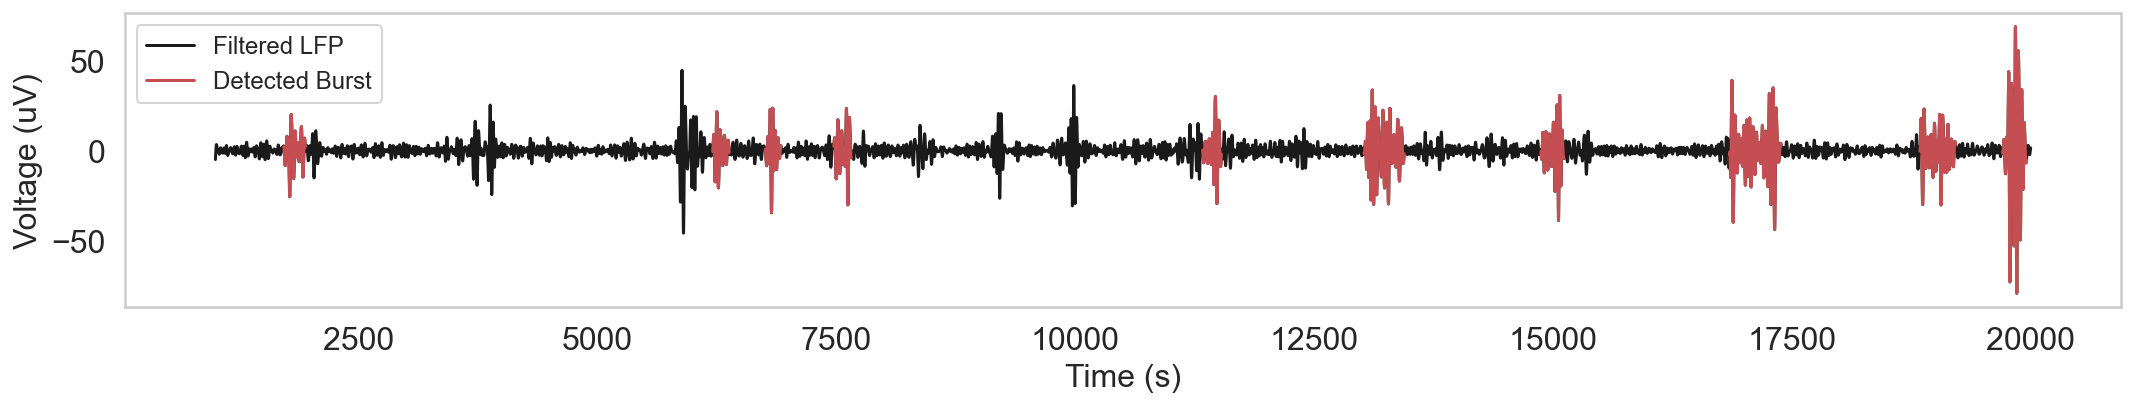

In [21]:
plot_bursts(lfp_times_c42[tidx], lfp_filt_gamma_c42[tidx], is_burst_gamma[tidx], labels=['Filtered LFP', 'Detected Burst'])


In [22]:
###Try neurodsp burst detection method 
is_burst = detect_bursts_dual_threshold(lfp_filt_gamma_c42, lfp_fs, dual_thresh=(2, 1), f_range=(gamma_peak - 15, gamma_peak+15))


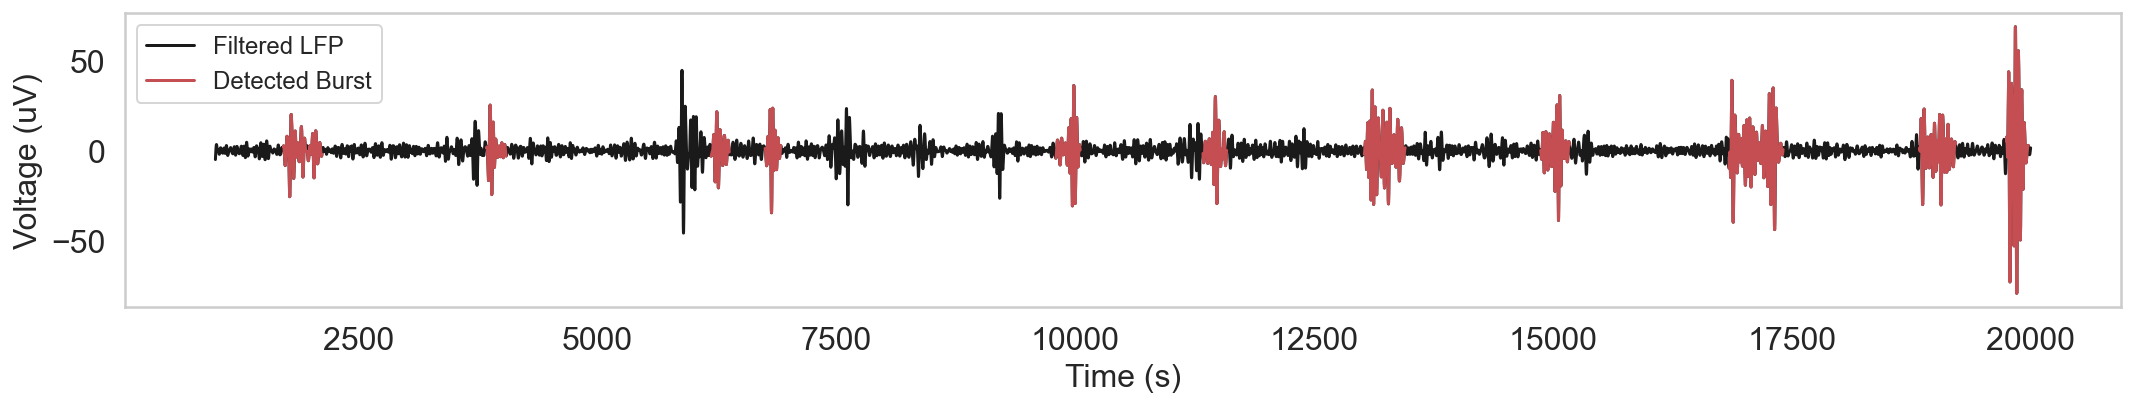

In [23]:
plot_bursts(lfp_times_c42[tidx], lfp_filt_gamma_c42[tidx], is_burst[tidx], labels=['Filtered LFP', 'Detected Burst'])


### Load and analyze extracellular spike data

In [ ]:
# load npx data
npx_file_dir = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/c42/'
npx_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/c42/c42_npx_raw-001.bin'
npx_fs = 30000 # sampling rate
npx_one_ms = int(npx_fs / 1000)
npx_channels = 384
npx_patch_channel = 109
npx_recording = np.memmap(npx_path, mode = 'r', dtype=np.int16, order = 'C')
npx_samples = int(len(npx_recording)/npx_channels)
npx_recording = npx_recording.reshape((npx_channels, npx_samples), order = 'F')
npx_recording = npx_recording[npx_patch_channel, :]
npx_recording = np.asarray(npx_recording)
npx_times = np.arange(0, np.shape(npx_recording)[0]) / npx_one_ms # in ms instead of sec
# filter the neuropixels data
npx_filt = butter_bandpass(npx_recording, fs=npx_fs, filt_freq=[300, 14000], order=4)
np.save(npx_file_dir + 'npx_filt.npy', npx_filt)

In [ ]:
# open and load the data
npx_filt = np.load(npx_file_dir + 'npx_filt.npy')

In [ ]:
plt.plot(npx_filt[0:100000])

#### Detect extracellular spikes

In [ ]:
sp_ex = Spike(thresh_amp=41.5, window_length=(5., 5.), smooth_frac=.01)

"""sp.alt(lfp_filt, lfp_fs, compute_alt_features, queue=True,
       param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))"""

sp_ex.fit(npx_filt, npx_fs, n_jobs=-1, progress=tqdm)

In [ ]:
sp_ex.df_features

In [ ]:
sp_ex.plot()

In [ ]:
##fix shaping broadcast error in fit function
sp_ex.spike_inds

### Compute patch clamp spike features for cell 42

#### 4. compare the patched spike waveform for spikes that occur during an obvious gamma burst versus those are are obviously not in gamma. We’ll want to confirm this visually, looking at the time series as well.


In [ ]:
patch_files = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/patch_recordings/'
patch_ch1 = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/patch_recordings/c42_patch_ch1.bin'


In [ ]:
#load patch clamp data for cell 42
patch_fs = 50023.88170476
patch_one_ms = int(patch_fs / 1000)
patch_recording = np.fromfile(patch_ch1, dtype='float64')
patch_recording = np.asarray(patch_recording)
#patch_recording = -patch_recording # positive up


patch_times = np.arange(0, np.shape(patch_recording)[0]) / patch_one_ms # in ms instead of sec

# filter the patch data
patch_filt = butter_bandpass(patch_recording, fs=patch_fs, filt_freq=[10, 25000], order=4)
np.save(patch_files + 'patch_filt_c42.npy', patch_filt)

In [ ]:
patch_filt_dir = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/patch_recordings/patch_filt_c42.npy'


In [ ]:
patch_filt = np.load(patch_filt_dir)
patch_times = np.arange(0, np.shape(patch_filt)[0]) / patch_one_ms # in ms instead of sec

In [ ]:
plt.plot(patch_times, patch_filt)

In [ ]:
lfp_times_c42

In [ ]:
patch_times

In [ ]:
plt.plot(patch_times[10000:1000000], patch_filt[10000:1000000])

In [ ]:
def compute_alt_features(stim, fs):
    return stim.mean(), stim.std()

#threshold in mVs
sp = Spike(thresh_amp=18, window_length=(5., 5.), smooth_frac=.01)

"""sp.alt(lfp_filt, lfp_fs, compute_alt_features, queue=True,
       param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))"""

sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm)

In [ ]:
sp.df_features

In [ ]:
# First 100 fits
sp.plot(inds=np.arange(800))

### Use detected spike indeces to determine if a spike occured during gamma peak or not

#### A) Figure out index conversion between LFP times and patch clamp times 

"""
m = len(patch_filt)/float( len(lfp_times_c42))


neuropixel_event = int(patch_fs / m)
patch_event = int(lfp_fs * m)"""


In [ ]:
m = 25 ##double check this 

#### B) Get converted indices for gamma 'bursts'

In [ ]:
burst_gamma = pd.Series(is_burst_gamma)

In [ ]:
#get start and end times for burst idx 
t=burst_gamma[burst_gamma].index.to_series()
burst_gamma_idx = t.groupby(t.diff().ne(1).cumsum()).agg(['first','last']).apply(tuple,1).tolist()

In [ ]:
burst_gamma_idx

#### C) Get converted indices for lowest amp no gamma 'bursts'. Select areas not in bursts with the lowest analytic amplitude

In [ ]:
#get indices for no burst idx 
no_burst_gamma = pd.Series(~is_burst_gamma)

In [ ]:
#get start and end times for noburst idx 
nt=no_burst_gamma[no_burst_gamma].index.to_series()
no_burst_gamma_idx = nt.groupby(nt.diff().ne(1).cumsum()).agg(['first','last']).apply(tuple,1).tolist()


In [ ]:
no_burst_mean_amp = []
no_burst_mean_ranges = []

for r in no_burst_gamma_idx:
    
    am_range = gamma_amp[slice(*r)]
    #take mean of analytic amplitude for that range 
    mean_am = np.nanmean(am_range )
    
    no_burst_mean_amp.append(mean_am)
    no_burst_mean_ranges.append(r)
    


In [ ]:
#Select 25% no burst sections with lowest analytical amplitude 
n_lowest = int(len(no_burst_mean_amp) * 0.25)
no_burst_mean_amp_array = np.array(no_burst_mean_amp, dtype=np.float32)
lowest_amp_no_bursts = no_burst_mean_amp_array.argsort()[:n_lowest]

#get the index range of the sections with lowest amplitude 


In [ ]:
no_burst_gamma_idx

In [ ]:
no_burst_gamma_idx[lowest_amp_no_bursts]

#### D) Determine what spikes are in which group 

In [ ]:
lfp_times_c42[tidx], lfp_filt_gamma_c42[tidx], is_burst_gamma[tidx]

In [ ]:
len(lfp_times_c42)

In [ ]:
len(patch_times)

In [ ]:
is_burst_gamma

In [ ]:
sp.spike_inds

In [ ]:
sp.df_features

In [ ]:
sp.df_features.isnull().values.any()

In [ ]:
# Ensure inflection times are between 0 and 2 ms
df_drop = sp.df_features.loc[sp.df_features['inflection_time'] > 0.]
df_drop = df_drop.loc[df_drop['inflection_time'] < 2.]

# Remove low r-squares (ramping fits are especially noisy)
df_drop = df_drop.loc[df_drop['r_squared_exp']  >= .5]
df_drop = df_drop.loc[df_drop['r_squared_ramp'] >= .1]

# log10 ISIs
df_drop[['isi']] = np.log10(df_drop[['isi']])

# drop no-longer-used QC features
df_drop = df_drop.drop(['r_squared_exp', 'r_squared_ramp'], axis=1)

# Rotate labels
axes = pd.plotting.scatter_matrix(df_drop, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
    
plt.show()

In [ ]:
spikes_corr = df_drop.corr()

# Plot the heatmap and annotation on it
sns.heatmap(spikes_corr, xticklabels=spikes_corr.columns, yticklabels=spikes_corr.columns, annot=True)
plt.show()

rho = df_drop.corr()
pval = df_drop.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.applymap(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p